##  Baseline model

In [1]:
!pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn pillow tqdm openpyxl

Loading and importing libraries

In [1]:
# Importing the necessary libraries
import os
import gc
import copy
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

## 1. Configuration

setting up the training configuration and dataset parameters. Tuning hyperparameters such as image size (160), batch size (16), epochs (16), learning rate (1e-3), and early stopping patience (3). The FREEZE_BACKBONE = True setting enables full fine-tuning of the pretrained model.

In [2]:
# Configurations
DATA_ROOT = r"C:\Users\Leona\Desktop\AI in Healthcare\BreakHis - Breast Cancer Histopathological Database\dataset_cancer_v1\classificacao_multiclasse"
MAGNIFICATION_FOLDER = "100X"

DEVICE = torch.device("cpu")
IMG_SIZE = 160
BATCH_SIZE = 16
NUM_EPOCHS = 16
LEARNING_RATE = 1e-3
NUM_WORKERS = 0
PATIENCE = 3
FREEZE_BACKBONE = True

CLASS_NAMES = ["adenosis", "ductal_carcinoma", "fibroadenoma", "lobular_carcinoma", "mucinous_carcinoma", "papillary_carcinoma", "phyllodes_tumor", "tubular_adenoma"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CLASS_NAMES)

print("Using device:", DEVICE)

Using device: cpu


In [17]:
#Label extraction and image collection

def infer_label_from_path(path_str):
    path_upper = str(path_str).replace("\\", "/").upper()
    parts_upper = [p.upper() for p in Path(path_str).parts]

    for cls_name in CLASS_NAMES:
        if cls_name.upper() in parts_upper:
            return cls_name

    for cls_name in sorted(CLASS_NAMES, key=len, reverse=True):
        token = cls_name.upper()
        if f"/{token}/" in path_upper:
            return cls_name
        if f"_{token}_" in path_upper:
            return cls_name
        if path_upper.endswith(f"_{token}.PNG"):
            return cls_name
        if path_upper.endswith(f"_{token}.JPG"):
            return cls_name
        if path_upper.endswith(f"_{token}.JPEG"):
            return cls_name

    return None


def collect_breakhis_images(data_root, magnification_folder="100X"):
    mag_path = Path(data_root) / magnification_folder
    if not mag_path.exists():
        raise FileNotFoundError(f"Folder not found: {mag_path}")

    valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    samples = []

    for img_path in mag_path.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in valid_exts:
            label_name = infer_label_from_path(str(img_path))
            if label_name is not None:
                samples.append((str(img_path), CLASS_TO_IDX[label_name]))

    if len(samples) == 0:
        raise ValueError(
            f"No labeled images found inside {mag_path}. "
            "Check your folder structure and class naming."
        )

    return samples

In [18]:
#Load all image paths and inspect class distribution
all_samples = collect_breakhis_images(DATA_ROOT, MAGNIFICATION_FOLDER)
all_paths = [s[0] for s in all_samples]
all_labels = [s[1] for s in all_samples]

print(f"Total images found: {len(all_samples)}")
print("\nOverall class distribution:")
for cls_idx, count in sorted(Counter(all_labels).items()):
    print(f"{IDX_TO_CLASS[cls_idx]}: {count}")

Total images found: 2081

Overall class distribution:
adenosis: 113
ductal_carcinoma: 903
fibroadenoma: 260
lobular_carcinoma: 170
mucinous_carcinoma: 222
papillary_carcinoma: 142
phyllodes_tumor: 121
tubular_adenoma: 150


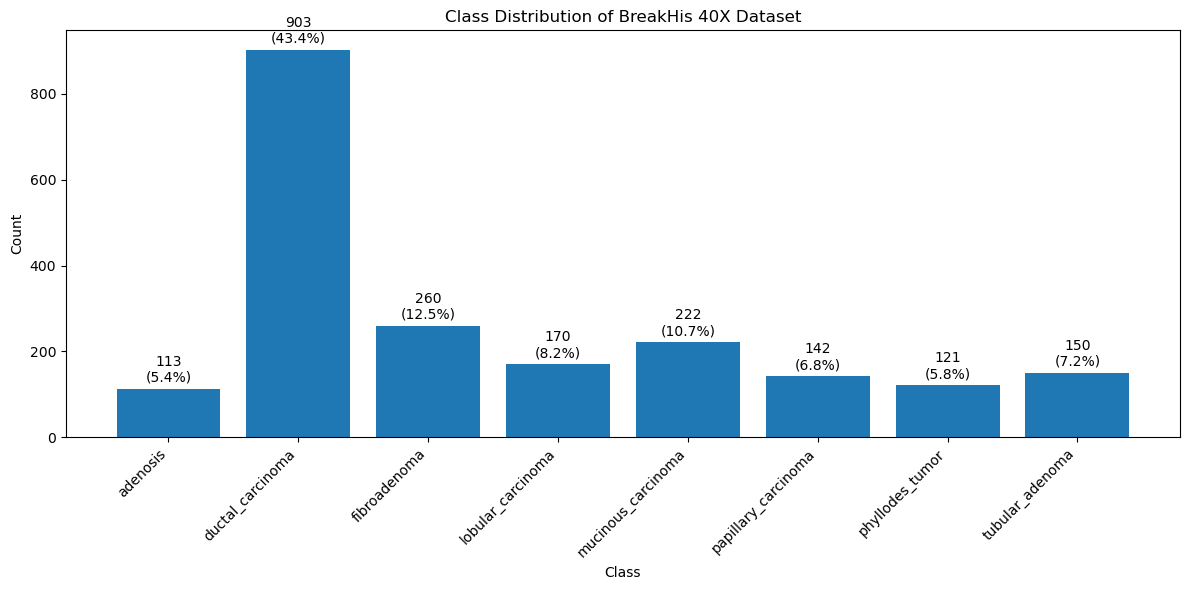

,Class,Count,Percentage
0,adenosis,113,5.430082
1,ductal_carcinoma,903,43.392600
2,fibroadenoma,260,12.493993
3,lobular_carcinoma,170,8.169149
4,mucinous_carcinoma,222,10.667948
5,papillary_carcinoma,142,6.823642
6,phyllodes_tumor,121,5.814512
7,tubular_adenoma,150,7.208073


In [5]:
# Plot class distribution with count and percentage
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

class_counts = Counter(all_labels)
total_images = len(all_labels)

# Create dataframe in class order
plot_df = pd.DataFrame({
    "Class": [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)],
    "Count": [class_counts.get(i, 0) for i in range(NUM_CLASSES)]
})

# Calculate percentage
plot_df["Percentage"] = (plot_df["Count"] / total_images) * 100

# Plot histogram
plt.figure(figsize=(12,6))
bars = plt.bar(plot_df["Class"], plot_df["Count"])

# Add count and percentage above each bar
for bar, count, pct in zip(bars, plot_df["Count"], plot_df["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(plot_df["Count"])*0.01,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Class Distribution of BreakHis 40X Dataset")
plt.xlabel("Class")
plt.ylabel("Count")

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Display summary table
display(plot_df)

In [6]:
#Stratified train/validation/test split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=42,
    shuffle=True
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42,
    shuffle=True
)

print("Split sizes:")
print(f"Train: {len(train_paths)}")
print(f"Val:   {len(val_paths)}")
print(f"Test:  {len(test_paths)}")

Split sizes:
Train: 1456
Val:   312
Test:  313


In [7]:
#Dataset class
class BreakHisDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        with Image.open(image_path) as img:
            image = img.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
#Preprocessing and transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = BreakHisDataset(train_paths, train_labels, transform=train_transform)
val_dataset = BreakHisDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = BreakHisDataset(test_paths, test_labels, transform=eval_transform)

print("Datasets created successfully.")

Datasets created successfully.


In [9]:
#WeightedRandomSampler and DataLoaders
train_class_counts = Counter(train_labels)

print("Training class distribution:")
for cls_idx, count in sorted(train_class_counts.items()):
    print(f"{IDX_TO_CLASS[cls_idx]}: {count}")

class_weights = {cls: 1.0 / count for cls, count in train_class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print("DataLoaders created successfully.")

Training class distribution:
adenosis: 79
ductal_carcinoma: 632
fibroadenoma: 182
lobular_carcinoma: 119
mucinous_carcinoma: 155
papillary_carcinoma: 99
phyllodes_tumor: 85
tubular_adenoma: 105
DataLoaders created successfully.


In [10]:
# Model building function
def build_model(model_name, num_classes):
    model_name = model_name.lower()

    if model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

        if FREEZE_BACKBONE:
            for name, param in model.named_parameters():
                if not name.startswith("fc"):
                    param.requires_grad = False

    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT
        model = models.densenet121(weights=weights)
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

        if FREEZE_BACKBONE:
            for name, param in model.named_parameters():
                if not name.startswith("classifier"):
                    param.requires_grad = False

    elif model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

        if FREEZE_BACKBONE:
            for name, param in model.named_parameters():
                if not name.startswith("classifier"):
                    param.requires_grad = False

    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    return model

In [11]:
#Evaluation function
@torch.no_grad()
def evaluate_model(model, loader, criterion, device, num_classes):
    model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        total_loss += loss.item() * images.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
    except Exception:
        roc_auc = np.nan

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [12]:
#Training one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [13]:
#Full training loop with early stopping
def train_model(model_name, train_loader, val_loader, device, num_classes):
    print("=" * 60)
    print(f"Training model: {model_name}")
    print("=" * 60)

    model = build_model(model_name, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=LEARNING_RATE)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    patience_counter = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate_model(model, val_loader, criterion, device, num_classes)

        record = {
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_precision_macro": train_metrics["precision_macro"],
            "train_recall_macro": train_metrics["recall_macro"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision_macro": val_metrics["precision_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_roc_auc_macro_ovr": val_metrics["roc_auc_macro_ovr"]
        }
        history.append(record)

        print(
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train F1: {train_metrics['f1_macro']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val F1: {val_metrics['f1_macro']:.4f} | "
            f"Val AUC: {val_metrics['roc_auc_macro_ovr']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_wts)
    history_df = pd.DataFrame(history)

    gc.collect()
    return model, history_df

In [16]:
# Train and compare the 3 models
MODEL_NAMES = [
    "resnet50",
    "densenet121",
    "efficientnet_b0"
]

trained_models = {}
histories = []
summary_rows = []

for model_name in MODEL_NAMES:
    start_time = time.time()

    model, history_df = train_model(
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        num_classes=NUM_CLASSES
    )

    criterion = nn.CrossEntropyLoss()
    best_val_metrics = evaluate_model(model, val_loader, criterion, DEVICE, NUM_CLASSES)

    elapsed = time.time() - start_time

    trained_models[model_name] = model
    history_df["model"] = model_name
    histories.append(history_df)

    summary_rows.append({
        "model": model_name,
        "val_loss": best_val_metrics["loss"],
        "val_accuracy": best_val_metrics["accuracy"],
        "val_precision_macro": best_val_metrics["precision_macro"],
        "val_recall_macro": best_val_metrics["recall_macro"],
        "val_f1_macro": best_val_metrics["f1_macro"],
        "val_roc_auc_macro_ovr": best_val_metrics["roc_auc_macro_ovr"],
        "training_time_seconds": round(elapsed, 2)
    })

    torch.save(model.state_dict(), f"{model_name}_best_cpu_breakhis_40x.pth")
    gc.collect()

results_df = pd.DataFrame(summary_rows).sort_values(
    by="val_f1_macro", ascending=False
).reset_index(drop=True)

print("\nValidation comparison:")
display(results_df)

results_df.to_csv("model_comparison_cpu_breakhis_40x.csv", index=False)

best_model_name = results_df.loc[0, "model"]
best_model = trained_models[best_model_name]

print(f"\nBest model selected: {best_model_name}")

Training model: resnet50

Epoch 1/16


Train Loss: 1.7250 | Train F1: 0.3882 | Val Loss: 1.5832 | Val F1: 0.4200 | Val AUC: 0.8455

Epoch 2/16


Train Loss: 1.3637 | Train F1: 0.5413 | Val Loss: 1.3764 | Val F1: 0.5491 | Val AUC: 0.8882

Epoch 3/16


Train Loss: 1.2259 | Train F1: 0.5877 | Val Loss: 1.2328 | Val F1: 0.5471 | Val AUC: 0.9120

Epoch 4/16


Train Loss: 1.1083 | Train F1: 0.6415 | Val Loss: 1.1682 | Val F1: 0.5996 | Val AUC: 0.9200

Epoch 5/16


...

Train Loss: 0.8501 | Train F1: 0.7069 | Val Loss: 1.1453 | Val F1: 0.5283 | Val AUC: 0.9181

Epoch 15/16


Train Loss: 0.8632 | Train F1: 0.6964 | Val Loss: 1.0517 | Val F1: 0.5954 | Val AUC: 0.9257

Epoch 16/16


Train Loss: 0.9072 | Train F1: 0.6717 | Val Loss: 1.0717 | Val F1: 0.5504 | Val AUC: 0.9249
Early stopping triggered.

Validation comparison:


,model,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc_macro_ovr,training_time_seconds
0,resnet50,0.961098,0.705128,0.664625,0.696750,0.665136,0.937150,1660.56
1,densenet121,0.951821,0.679487,0.669392,0.655158,0.641911,0.931689,2113.66
2,efficientnet_b0,1.030413,0.641026,0.601117,0.649099,0.605743,0.925242,1107.68



Best model selected: resnet50


In [19]:
#Evaluate best model on the test set
criterion = nn.CrossEntropyLoss()
test_metrics = evaluate_model(best_model, test_loader, criterion, DEVICE, NUM_CLASSES)

print("=" * 60)
print("FINAL TEST PERFORMANCE")
print("=" * 60)
print(f"Best Model           : {best_model_name}")
print(f"Test Loss            : {test_metrics['loss']:.4f}")
print(f"Test Accuracy        : {test_metrics['accuracy']:.4f}")
print(f"Test Precision Macro : {test_metrics['precision_macro']:.4f}")
print(f"Test Recall Macro    : {test_metrics['recall_macro']:.4f}")
print(f"Test F1 Macro        : {test_metrics['f1_macro']:.4f}")
print(f"Test ROC-AUC Macro   : {test_metrics['roc_auc_macro_ovr']:.4f}")

FINAL TEST PERFORMANCE
Best Model           : resnet50
Test Loss            : 0.9289
Test Accuracy        : 0.6741
Test Precision Macro : 0.6465
Test Recall Macro    : 0.6626
Test F1 Macro        : 0.6375
Test ROC-AUC Macro   : 0.9440


In [20]:
#Classification report
print("Classification Report:\n")
print(classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

Classification Report:

                     precision    recall  f1-score   support

           adenosis     0.5833    0.8235    0.6829        17
   ductal_carcinoma     0.7934    0.7059    0.7471       136
       fibroadenoma     0.8519    0.5897    0.6970        39
  lobular_carcinoma     0.4444    0.6154    0.5161        26
 mucinous_carcinoma     0.6389    0.6765    0.6571        34
papillary_carcinoma     0.8571    0.5714    0.6857        21
    phyllodes_tumor     0.5294    0.5000    0.5143        18
    tubular_adenoma     0.4737    0.8182    0.6000        22

           accuracy                         0.6741       313
          macro avg     0.6465    0.6626    0.6375       313
       weighted avg     0.7101    0.6741    0.6806       313



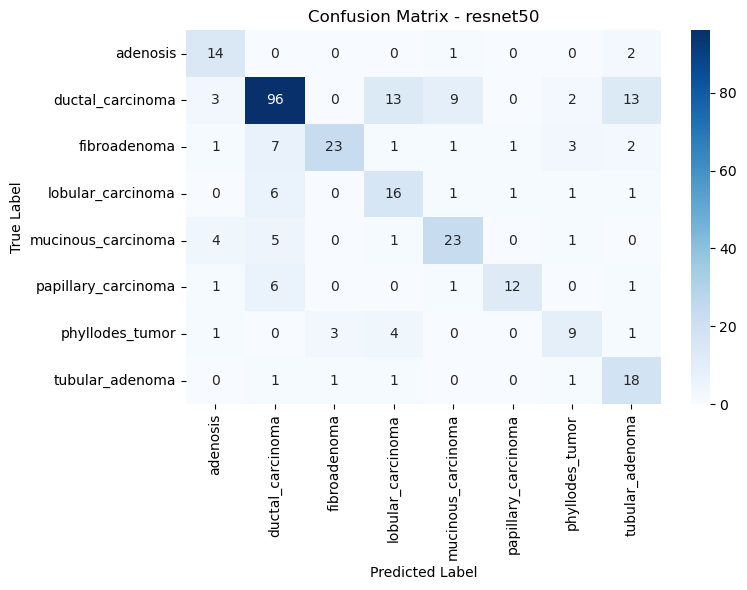

In [21]:
#Confusion matrix
cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

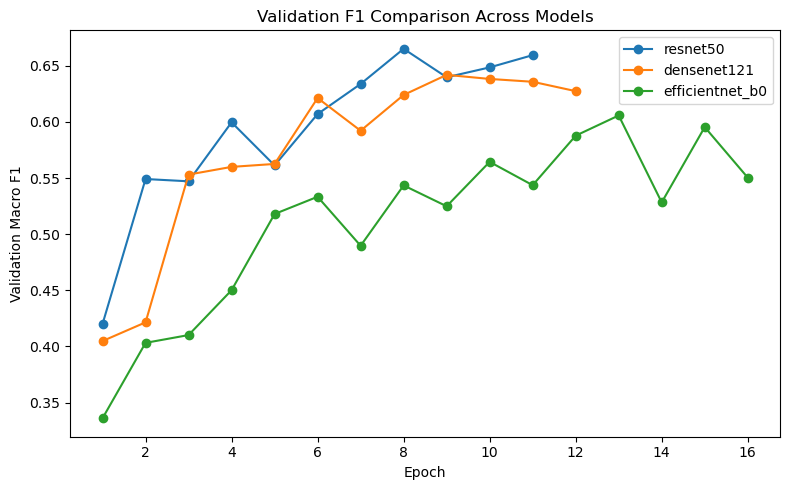

In [22]:
#Validation F1 comparison plot
history_all = pd.concat(histories, ignore_index=True)

plt.figure(figsize=(8, 5))
for model_name in MODEL_NAMES:
    sub = history_all[history_all["model"] == model_name]
    plt.plot(sub["epoch"], sub["val_f1_macro"], marker="o", label=model_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("Validation F1 Comparison Across Models")
plt.legend()
plt.tight_layout()
plt.savefig("validation_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Save test predictions
pred_df = pd.DataFrame({
    "true_label_index": test_metrics["y_true"],
    "predicted_label_index": test_metrics["y_pred"],
    "true_label_name": [IDX_TO_CLASS[i] for i in test_metrics["y_true"]],
    "predicted_label_name": [IDX_TO_CLASS[i] for i in test_metrics["y_pred"]]
})

pred_df.to_csv("test_predictions_best_model.csv", index=False)
display(pred_df.head())

print("Saved files:")
print("- model_comparison_cpu_breakhis_100x.csv")
print("- confusion_matrix_best_model.png")
print("- validation_f1_comparison.png")
print("- test_predictions_best_model.csv")
print(f"- {best_model_name}_best_cpu_breakhis_100x.pth")

,true_label_index,predicted_label_index,true_label_name,predicted_label_name
0,1,1,ductal_carcinoma,ductal_carcinoma
1,2,2,fibroadenoma,fibroadenoma
2,4,4,mucinous_carcinoma,mucinous_carcinoma
3,1,1,ductal_carcinoma,ductal_carcinoma
4,1,1,ductal_carcinoma,ductal_carcinoma


Saved files:
- model_comparison_cpu_breakhis_40x.csv
- confusion_matrix_best_model.png
- validation_f1_comparison.png
- test_predictions_best_model.csv
- resnet50_best_cpu_breakhis_100x.pth
